# Подготовка модели для предсказания массы морских черепах

В рамках данного проекта необходимо разработать систему компьютерного зрения, которая сможет бесконтактным способом прогнозировать массу черепах, опираясь на замеры. Это поможет решить проблему получения стресса черепахами, неудобства при физическом взвешивании для персонала (необходимость поднимать черепах).
В рамках моей задачи необходимо разработать и исследовать модель линейной регрессии на основе полученных данных, которая будет использоваться в системе компьютерного зрения

## Постановка задачи машинного обучения

В рамках данного проекта нам необходимо решить задачу регрессии, через модель линейной регрессии. Целевой переменной установим поле weight - масса черепахи. 
Для оценки качества модели будем использовать метрику МАЕ, как основную, и MSE, R², MAPE как дополнительные. Критерием успешной модели будет значение метрики MAE не более 5 кг, а также модель должна объяснять большую часть вариативности массы, потому метрика R² должна быть не ниже 0.97. Также необходимо расчитать среднюю ошибку в относительном значении (MAPE)

## Подключение и настройка библиотек

In [4]:
# Установка sklearn версии 1.7.0

pip install scikit-learn==1.7.0

SyntaxError: invalid syntax (415361385.py, line 3)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error

## Загрузка датасета

In [2]:
df = pd.read_csv('/Users/mymensk/ya_project/turtles.csv', sep='\t', decimal=',')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mymensk/ya_project/turtles.csv'

In [4]:
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [5]:
# Выведем информацию о загруженном датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

In [6]:
# Выведем детальную статистику по полям датасета

df.describe()

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
count,8861.000000,8774.000000,8861.000000,8715.000000,8715.000000,8861.000000,8861.000000,8861.000000,8861.000000,8760.000000,8760.000000,8760.000000,8760.000000,8861.000000,8597.000000,2176.000000,8.861000e+03,8842.000000
mean,21359.335628,764.222020,598.832299,123.341021,115.735169,497.551405,380.594515,498.228530,380.687507,397.953196,304.405251,397.853196,305.030023,41.002821,2.477143,1.671415,1.712640e+09,79.163138
std,2263.089420,640.408681,480.970492,67.836566,62.326365,353.575213,214.481679,355.074883,213.485239,282.970532,171.172490,281.983591,171.540535,36.995874,1.116564,1.131790,2.292273e+07,95.877609
min,17438.000000,132.000000,78.000000,19.000000,12.000000,60.000000,34.000000,57.000000,33.000000,50.000000,27.000000,44.000000,25.000000,0.000000,1.000000,1.000000,1.672570e+09,0.000000
25%,19396.000000,440.000000,341.000000,73.000000,67.000000,296.000000,228.000000,296.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,1.000000,1.693001e+09,31.109500
50%,21357.000000,635.000000,487.000000,106.000000,98.000000,416.000000,332.000000,417.000000,330.000000,333.000000,264.000000,333.000000,266.000000,35.000000,2.000000,1.000000,1.712804e+09,41.140500
75%,23317.000000,951.000000,794.000000,158.000000,156.000000,571.000000,493.000000,572.000000,500.000000,457.000000,397.000000,456.000000,396.000000,73.000000,3.000000,2.000000,1.732902e+09,85.239500
max,25279.000000,20240.000000,11550.000000,515.000000,382.000000,2875.000000,1479.000000,2967.000000,1402.000000,2279.000000,1280.000000,2406.000000,1313.000000,178.000000,4.000000,5.000000,1.751608e+09,617.777000


Похоже, в данных есть выбросы: часть измерений по параметрам длины, ширины черепах, а также длины ласт - не соответствуют реалистичным. В дальнейшем придется произвести их обработку. 
В поле с весом (целевая переменная - есть нулевые значения) - их также придется обработать.
Также в выборке присутствуют технические столбцы: id, количество измерений, время внесения данных - которые не влияют на массу и могут исказить модель. Их придется удалить на этапе предобработки

## Исследовательский анализ данных

In [7]:
# 1. Выведем данные о видах черепах, представленных в выборке

df['binomial_name'].unique()

array(['Caretta caretta', 'Lepidochelys olivacea',
       'LEPIDOCHELYS OLIVACEA', 'Lepidochelys Olivacea',
       'lepidochelys olivacea', 'Chelonia mydas',
       'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata',
       'Dermochelys coriacea', 'caretta caretta', 'CARETTA CARETTA',
       'chelonia mydas', 'Chelonia Mydas', 'CHELONIA MYDAS',
       'Dermochelys Coriacea', 'eretmochelys imbricata', nan,
       'Caretta Caretta', 'lepidochelys kempii', 'Lepidochelys kempii',
       'Eretmochelys Imbricata', 'dermochelys coriacea',
       'Lepidochelys Kempii', 'DERMOCHELYS CORIACEA'], dtype=object)

Так как названия записаны в разном регистре, для корректной фильтрации необходимо привести все записи к нижнему регистру

In [8]:
df['binomial_name'] = df['binomial_name'].str.lower()
df['binomial_name'].unique()

array(['caretta caretta', 'lepidochelys olivacea', 'chelonia mydas',
       'eretmochelys imbricata', 'dermochelys coriacea', nan,
       'lepidochelys kempii'], dtype=object)

In [9]:
# 2. Отфильтруем записи по нужному нам виду: Chelonia mydas. В дальнейшем будем работать с отфильтрованным датафреймом

# Фильтруем
df_filtered = df.loc[df['binomial_name'] == 'chelonia mydas']

# Проверяем
print(df_filtered['binomial_name'].unique())

df_filtered.info()

['chelonia mydas']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count       

3. Удалим лишние признаки

Для построения модели предсказания массы необходимо оставить только те признаки, которые на нее влияют.
Лишние признаки могут исказить модель. В нашем случае необходимо удалить столбцы: id (идентификатор записи), binomial_name (название вида), registration number (регномер черепахи), measure_count (количество измерений), timestamp (время измерения), 'shell_crack' (наличие трещин панциря)

In [10]:
# Удаляем
df_filtered = df_filtered.drop(columns=['id', 'binomial_name', 'registration number', 'measure_count', 'shell_crack', 'timestamp']).reset_index(drop=True)

# Проверяем

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2829 entries, 0 to 2828
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2794 non-null   float64
 1   shell_width       2829 non-null   int64  
 2   head_length       2790 non-null   float64
 3   head_width        2790 non-null   float64
 4   flipper_length_1  2829 non-null   int64  
 5   flipper_width_1   2829 non-null   int64  
 6   flipper_length_2  2829 non-null   int64  
 7   flipper_width_2   2829 non-null   int64  
 8   flipper_length_3  2798 non-null   float64
 9   flipper_width_3   2798 non-null   float64
 10  flipper_length_4  2798 non-null   float64
 11  flipper_width_4   2798 non-null   float64
 12  circle_count      2829 non-null   int64  
 13  weight            2826 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 309.5 KB


In [11]:
# 4. Анализ пропусков в датафрейме

df_filtered.isna().sum()

shell_length        35
shell_width          0
head_length         39
head_width          39
flipper_length_1     0
flipper_width_1      0
flipper_length_2     0
flipper_width_2      0
flipper_length_3    31
flipper_width_3     31
flipper_length_4    31
flipper_width_4     31
circle_count         0
weight               3
dtype: int64

Количество строк с пропусками небольшое, порядка 1%. Подобные пропуски могут быть связаны с работой датчиков/оборудования для измерения. Данные пропуски можно будет заполнить или удалить после разделения выборок.
Пропуски по полю с целевой переменной удалим на данном этапе

In [12]:
# Удаляем NaN значения
df_filtered = df_filtered.dropna(subset=['weight']).reset_index(drop=True)

# Фильтруем по значениям, чтобы отсечь вес 0.0
df_filtered = df_filtered.loc[df_filtered['weight'] > 0]

In [13]:
# Проверяем

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2823 entries, 0 to 2825
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2788 non-null   float64
 1   shell_width       2823 non-null   int64  
 2   head_length       2784 non-null   float64
 3   head_width        2784 non-null   float64
 4   flipper_length_1  2823 non-null   int64  
 5   flipper_width_1   2823 non-null   int64  
 6   flipper_length_2  2823 non-null   int64  
 7   flipper_width_2   2823 non-null   int64  
 8   flipper_length_3  2792 non-null   float64
 9   flipper_width_3   2792 non-null   float64
 10  flipper_length_4  2792 non-null   float64
 11  flipper_width_4   2792 non-null   float64
 12  circle_count      2823 non-null   int64  
 13  weight            2823 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 330.8 KB


In [14]:
# 5. Проверим наличие дубликатов по строкам и выведем их сумму

df_filtered.duplicated().sum().item()

340

Полностью дублирующиеся строки можно удалить, оставив первое вхождение в датафрейм

In [15]:
# Удалим дубликаты в данных

df_filtered = df_filtered.drop_duplicates(keep='first').reset_index(drop=True)

# Проверяем

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2454 non-null   float64
 1   shell_width       2483 non-null   int64  
 2   head_length       2448 non-null   float64
 3   head_width        2448 non-null   float64
 4   flipper_length_1  2483 non-null   int64  
 5   flipper_width_1   2483 non-null   int64  
 6   flipper_length_2  2483 non-null   int64  
 7   flipper_width_2   2483 non-null   int64  
 8   flipper_length_3  2454 non-null   float64
 9   flipper_width_3   2454 non-null   float64
 10  flipper_length_4  2454 non-null   float64
 11  flipper_width_4   2454 non-null   float64
 12  circle_count      2483 non-null   int64  
 13  weight            2483 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 271.7 KB


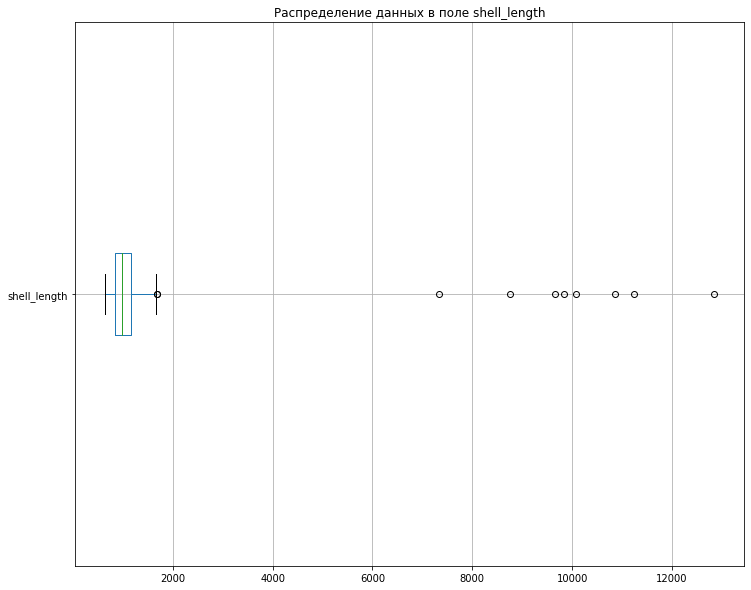

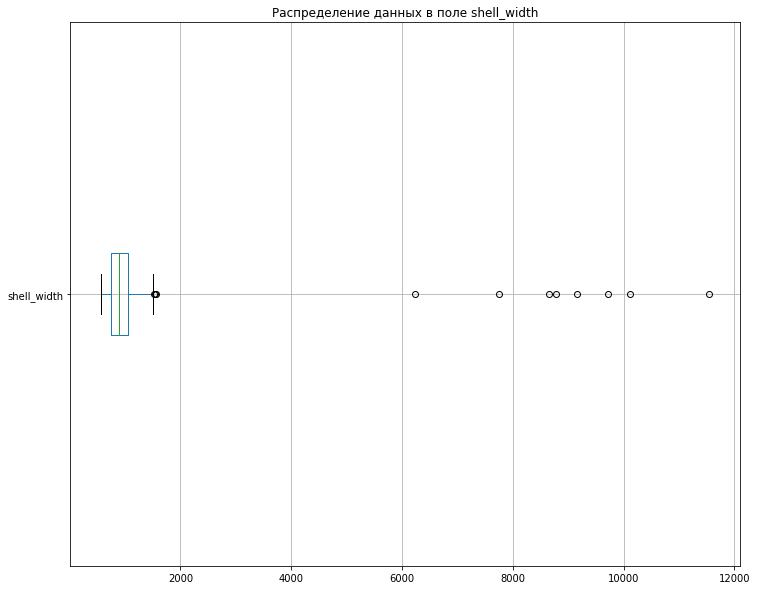

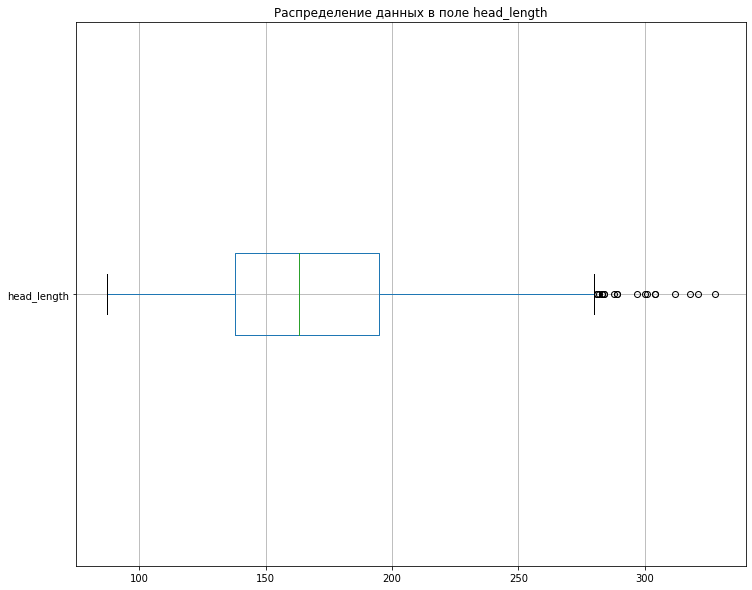

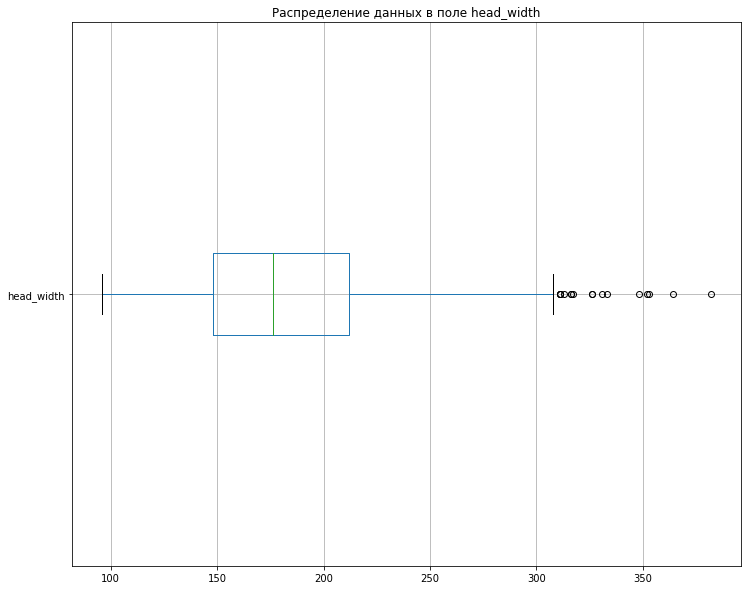

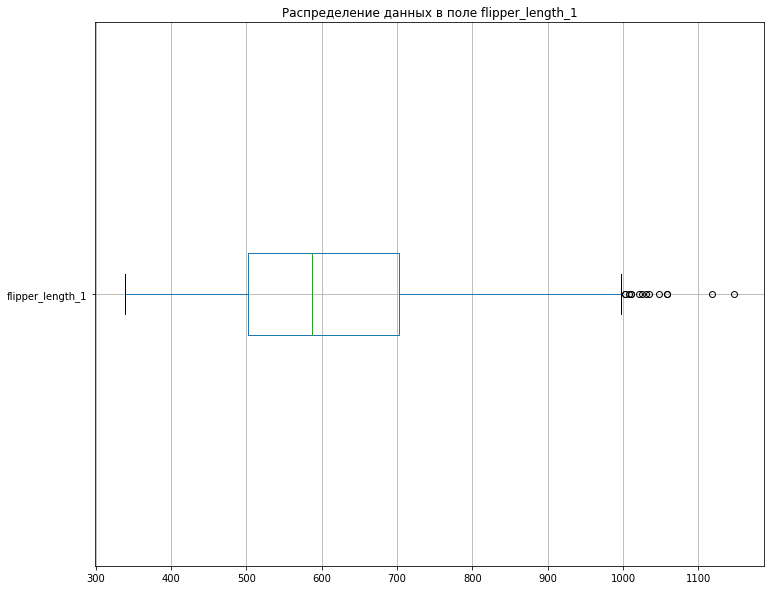

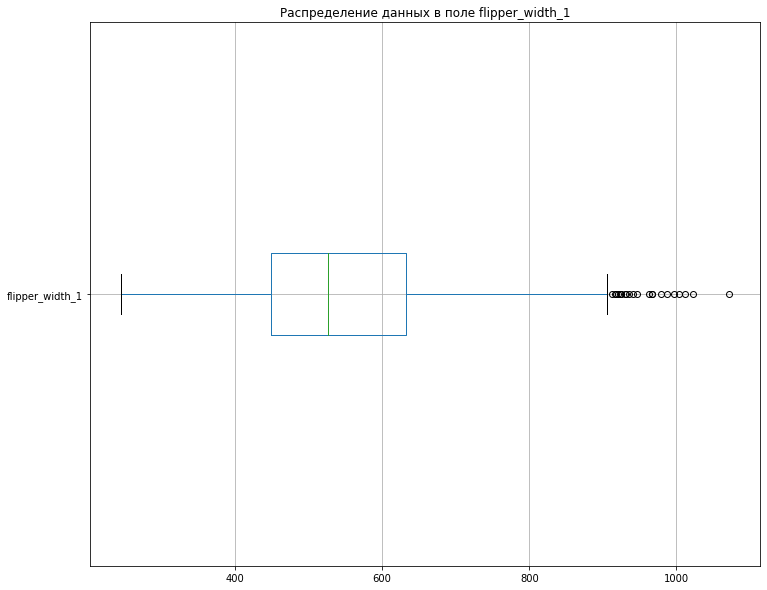

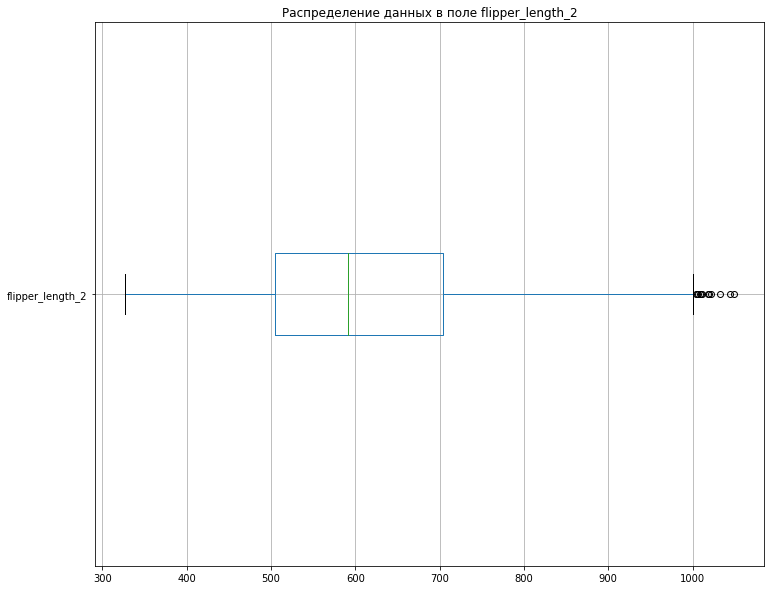

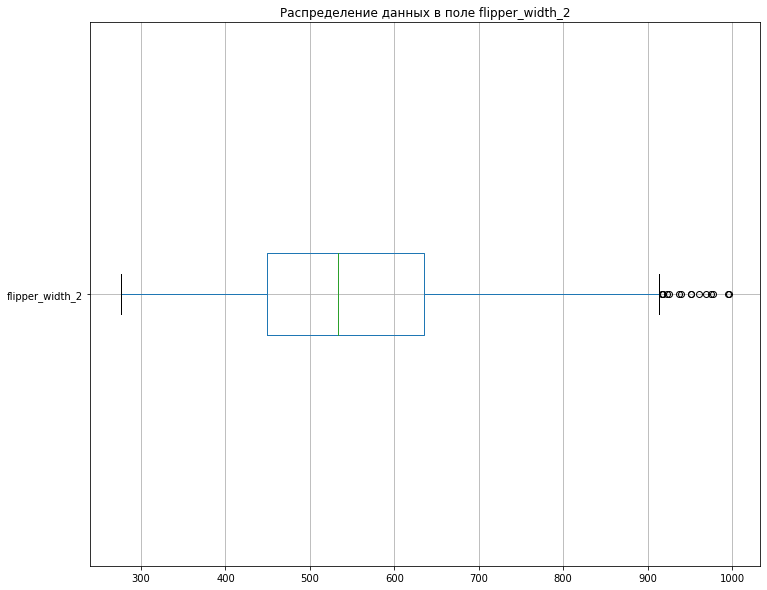

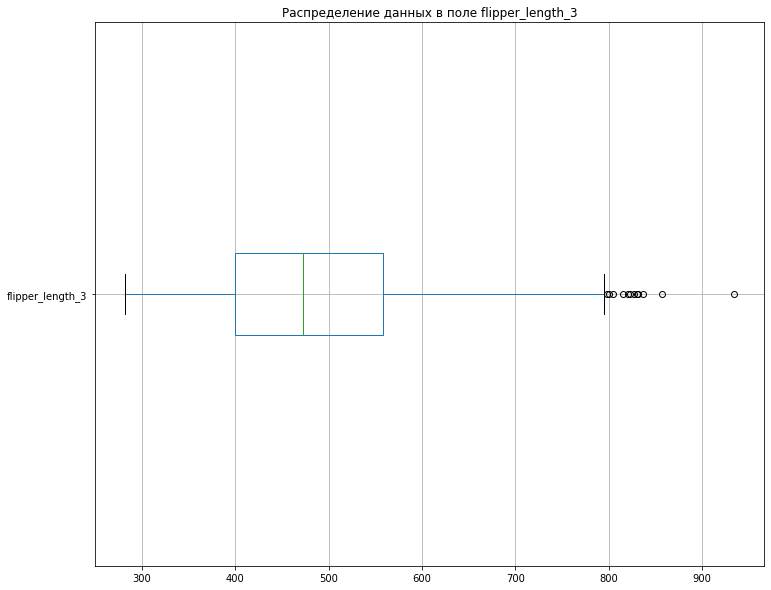

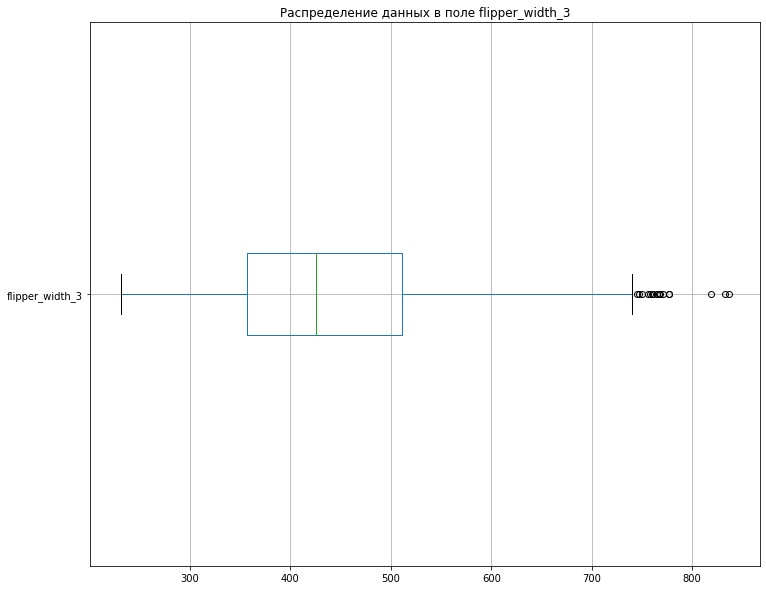

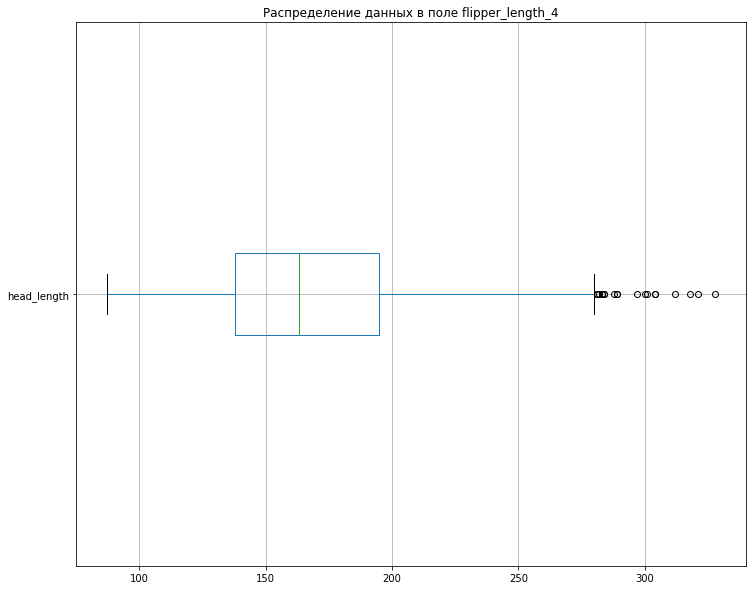

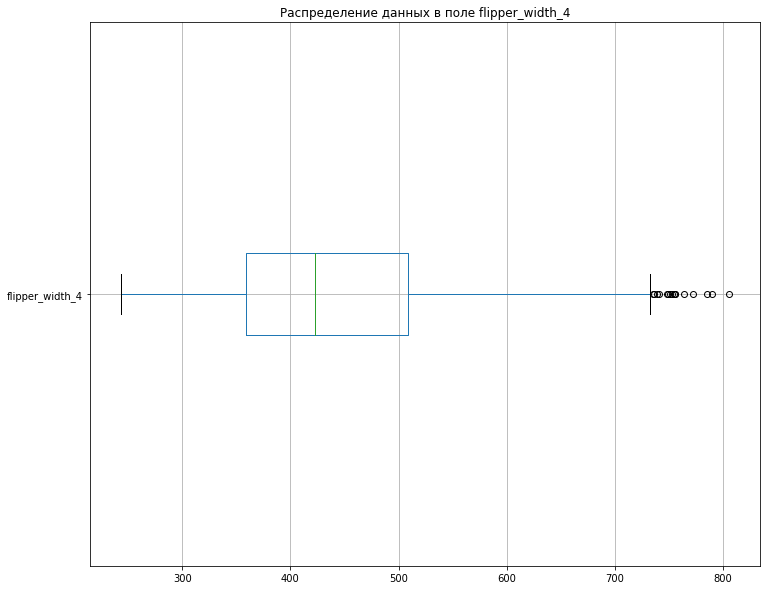

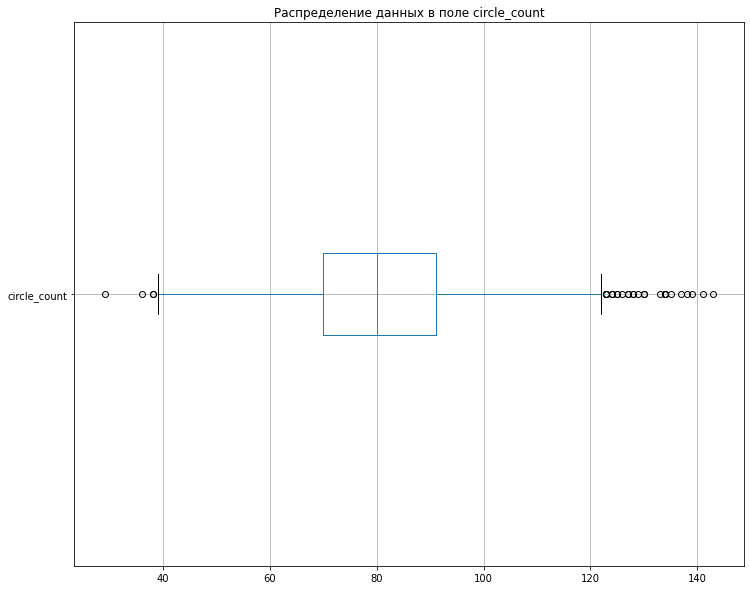

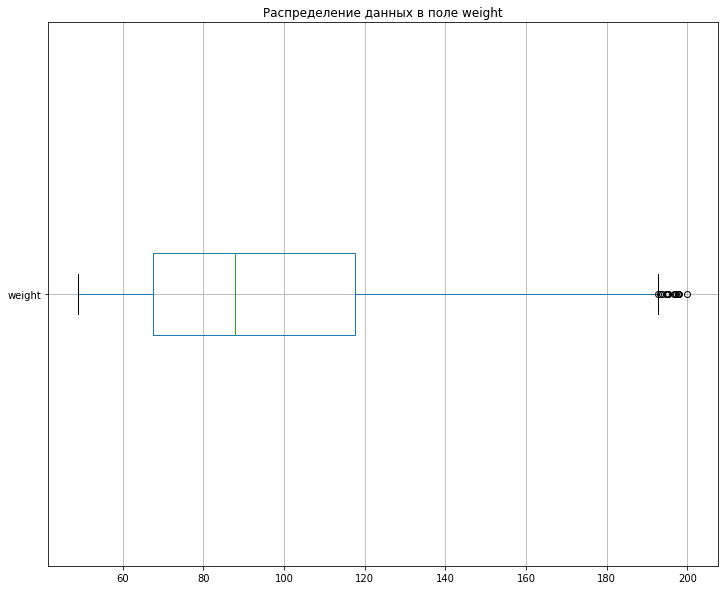

In [16]:
# 6. Исследуем данные на выбросы, построим гистограмму "ящик с усами" по параметрам выборки

plot1 = df_filtered.boxplot(column='shell_length',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot1.set_title('Распределение данных в поле shell_length')
plt.show()

plot2 = df_filtered.boxplot(column='shell_width',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot2.set_title('Распределение данных в поле shell_width')
plt.show()

plot3 = df_filtered.boxplot(column='head_length',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot3.set_title('Распределение данных в поле head_length')
plt.show()

plot4 = df_filtered.boxplot(column='head_width',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot4.set_title('Распределение данных в поле head_width')
plt.show()

plot5 = df_filtered.boxplot(column='flipper_length_1',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot5.set_title('Распределение данных в поле flipper_length_1')
plt.show()

plot6 = df_filtered.boxplot(column='flipper_width_1',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot6.set_title('Распределение данных в поле flipper_width_1')
plt.show()

plot7 = df_filtered.boxplot(column='flipper_length_2',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot7.set_title('Распределение данных в поле flipper_length_2')
plt.show()

plot8 = df_filtered.boxplot(column='flipper_width_2',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot8.set_title('Распределение данных в поле flipper_width_2')
plt.show()

plot9 = df_filtered.boxplot(column='flipper_length_3',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot9.set_title('Распределение данных в поле flipper_length_3')
plt.show()

plot10 = df_filtered.boxplot(column='flipper_width_3',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot10.set_title('Распределение данных в поле flipper_width_3')
plt.show()

plot11 = df_filtered.boxplot(column='head_length',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot11.set_title('Распределение данных в поле flipper_length_4')
plt.show()

plot12 = df_filtered.boxplot(column='flipper_width_4',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot12.set_title('Распределение данных в поле flipper_width_4')
plt.show()

plot13 = df_filtered.boxplot(column='circle_count',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot13.set_title('Распределение данных в поле circle_count')
plt.show()

plot14 = df_filtered.boxplot(column='weight',
           vert=False,
           grid=True,
           figsize=(12, 10))

plot14.set_title('Распределение данных в поле weight')
plt.show()

По графикам видно, что по всем показателям есть выбросы, которые лежат за правым "усом". 
По части данных, видно, что при вводе данных допущена ошибка, и некоторые данные по длине и ширине попали в выборку умноженными на 10 (в условии указано, что имела место быть ошибка волонтера)
Необходимо обработать эти данные, удалив такие строки. 


In [17]:
#Вычислим 99 персентиль по выборке:

df_filtered.quantile(0.99)

shell_length        1599.94000
shell_width         1449.62000
head_length          279.00000
head_width           303.00000
flipper_length_1     979.36000
flipper_width_1      903.00000
flipper_length_2     969.18000
flipper_width_2      899.18000
flipper_length_3     773.94000
flipper_width_3      719.82000
flipper_length_4     783.47000
flipper_width_4      718.47000
circle_count         123.00000
weight               189.66388
Name: 0.99, dtype: float64

Можно сделать вывод, что 99 персентиль отсекает некорректно внесенные данные: длина/ширина панциря попадает в описание вида (длина и ширина панциря соответствуют биологическому описанию  -  длина панциря до 150 см (в исключительных случаях до 200 см), ширина панциря - 80% от длины. Отфильтруем данные по 99 персентилю по длине и ширине панциря, и удалим строки с ошибочно введенными данными

In [18]:
# Сначала отфильтруем по длине и проверим выбросы
df_filtered = df_filtered[df_filtered['shell_length'] <= df_filtered['shell_length'].quantile(0.99)].reset_index(drop=True)

In [19]:
df_filtered.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
count,2429.000000,2429.000000,2396.000000,2396.000000,2429.000000,2429.000000,2429.000000,2429.000000,2402.000000,2402.000000,2402.000000,2402.000000,2429.000000,2429.000000
mean,1014.158501,915.084809,168.957846,182.492905,609.336352,547.610951,609.432277,548.244957,485.554954,438.745212,487.229808,439.170691,80.771511,95.486835
std,217.006318,198.242472,40.578472,44.427074,139.485717,129.919309,136.073722,128.830699,108.889119,103.335868,110.312421,102.458025,16.129523,34.102986
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,287.000000,231.000000,254.000000,243.000000,29.000000,49.045000
25%,836.000000,751.000000,138.000000,148.000000,501.000000,449.000000,504.000000,448.000000,399.000000,357.000000,400.000000,359.000000,70.000000,67.496000
50%,977.000000,886.000000,162.000000,175.000000,586.000000,526.000000,590.000000,532.000000,472.000000,424.000000,472.000000,422.000000,79.000000,87.695000
75%,1162.000000,1050.000000,194.000000,211.000000,700.000000,629.000000,702.000000,633.000000,556.000000,508.000000,561.000000,506.000000,91.000000,117.148000
max,1599.000000,1510.000000,321.000000,352.000000,1147.000000,1072.000000,1045.000000,997.000000,934.000000,837.000000,868.000000,806.000000,141.000000,197.905000


Скорее всего, ошибки были допущены в одних и тех же строках, и удаление строк по длине панциря заодно помогло нормализовать поле Ширина панциря

In [20]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429 entries, 0 to 2428
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2429 non-null   float64
 1   shell_width       2429 non-null   int64  
 2   head_length       2396 non-null   float64
 3   head_width        2396 non-null   float64
 4   flipper_length_1  2429 non-null   int64  
 5   flipper_width_1   2429 non-null   int64  
 6   flipper_length_2  2429 non-null   int64  
 7   flipper_width_2   2429 non-null   int64  
 8   flipper_length_3  2402 non-null   float64
 9   flipper_width_3   2402 non-null   float64
 10  flipper_length_4  2402 non-null   float64
 11  flipper_width_4   2402 non-null   float64
 12  circle_count      2429 non-null   int64  
 13  weight            2429 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 265.8 KB


7. Масштаб признаков не одинаковый: 12 из 13 признаков заданы в мм, а один - в штуках (число колец). Необходимо будет произвести их масштабирование на этапе предобработки.

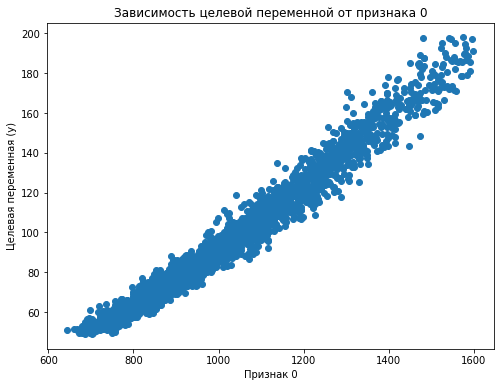

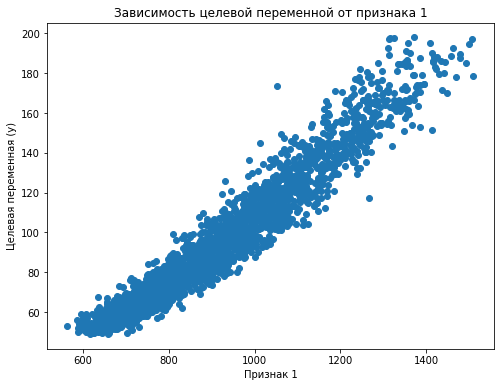

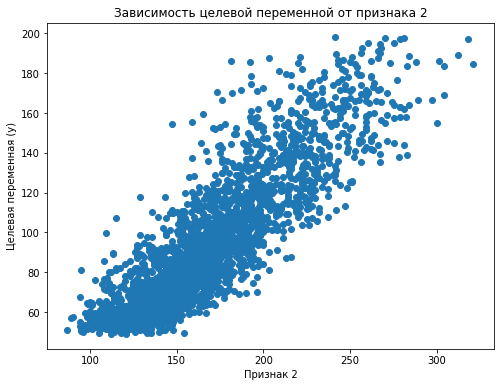

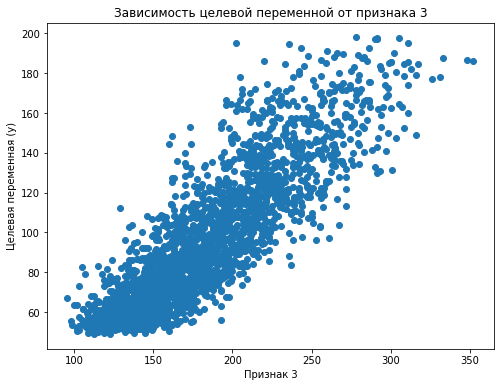

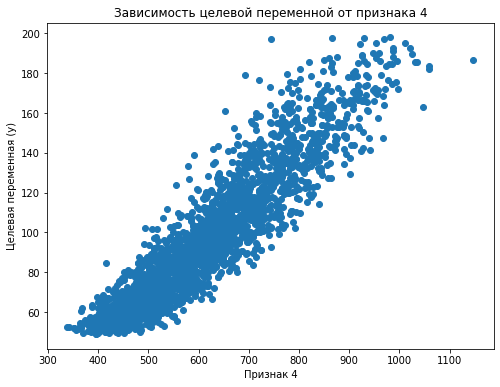

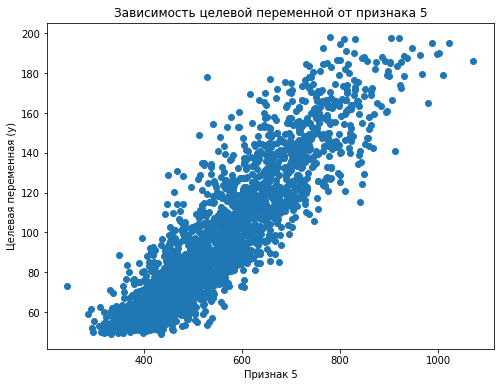

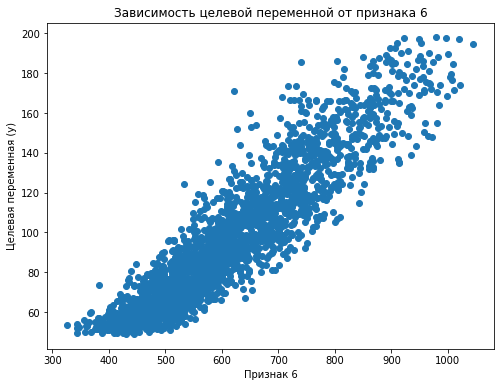

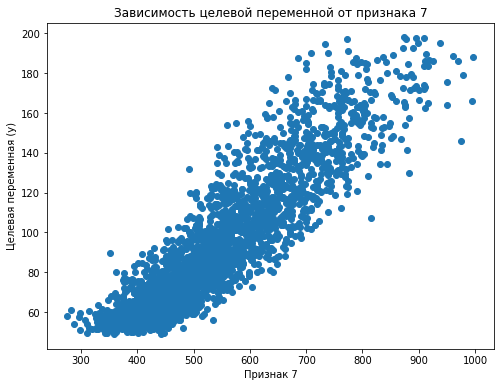

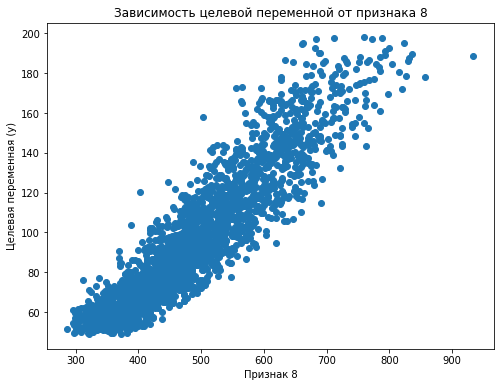

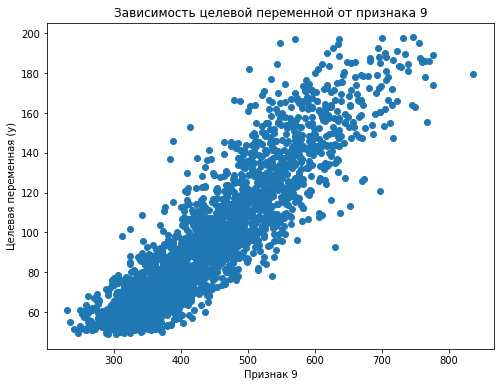

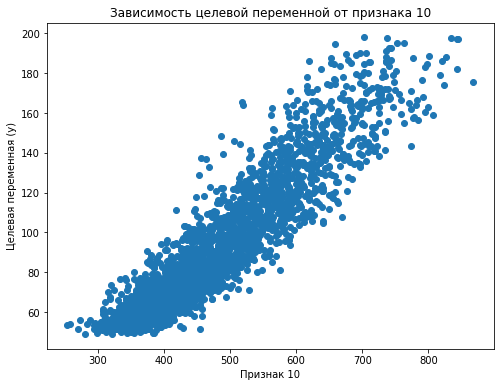

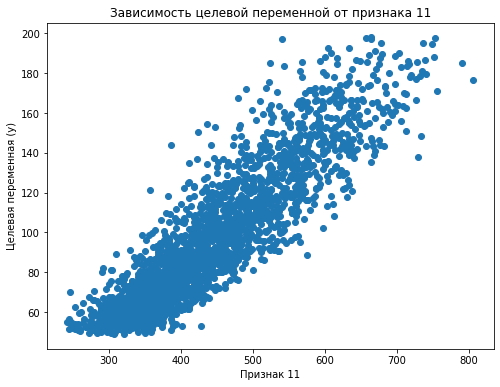

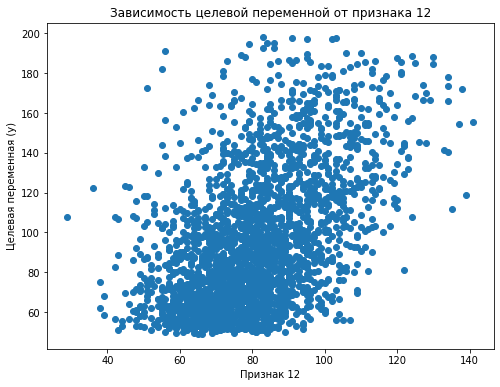

In [21]:
# 8. 

X = df_filtered.iloc[:, :-1] 
y = df_filtered.iloc[:, -1]

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], y)  
plt.title('Зависимость целевой переменной от признака 0')
plt.xlabel('Признак 0')
plt.ylabel('Целевая переменная (y)')
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 1], y)  
plt.title('Зависимость целевой переменной от признака 1')
plt.xlabel('Признак 1')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 2], y)  
plt.title('Зависимость целевой переменной от признака 2')
plt.xlabel('Признак 2')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 3], y)  
plt.title('Зависимость целевой переменной от признака 3')
plt.xlabel('Признак 3')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 4], y)  
plt.title('Зависимость целевой переменной от признака 4')
plt.xlabel('Признак 4')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 5], y)  
plt.title('Зависимость целевой переменной от признака 5')
plt.xlabel('Признак 5')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 6], y)  
plt.title('Зависимость целевой переменной от признака 6')
plt.xlabel('Признак 6')
plt.ylabel('Целевая переменная (y)')
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 7], y)  
plt.title('Зависимость целевой переменной от признака 7')
plt.xlabel('Признак 7')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 8], y)  
plt.title('Зависимость целевой переменной от признака 8')
plt.xlabel('Признак 8')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 9], y)  
plt.title('Зависимость целевой переменной от признака 9')
plt.xlabel('Признак 9')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 10], y)  
plt.title('Зависимость целевой переменной от признака 10')
plt.xlabel('Признак 10')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 11], y)  
plt.title('Зависимость целевой переменной от признака 11')
plt.xlabel('Признак 11')
plt.ylabel('Целевая переменная (y)')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 12], y)  
plt.title('Зависимость целевой переменной от признака 12')
plt.xlabel('Признак 12')
plt.ylabel('Целевая переменная (y)')
plt.show()

Из визуализации можно сделать вывод, что признаки 0 и 1 показывают похожий вид зависимости целевой переменной от них. Аналогичная ситуация и с признаками 2-3, и 4-11. Признак 12 показывает слабую корелляцию. 
Для отбора значимых признаков будут расчитаны модели с регуляризацей (Lasso, Ridge). Также данные виды регуляризации будут полезны для борьбы с мультиколлинеарностью

## Предобработка данных

In [22]:
# Разделим данные на 3 выборки: обучающая, валидационная и тестовая

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=42)
# Выделите на train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                    test_size=0.25,
                                                    shuffle=True,
                                                    random_state=42)

In [23]:
# Проверим распределение данных по признакам

X_train.info()
X_val.info()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1457 entries, 1353 to 68
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      1457 non-null   float64
 1   shell_width       1457 non-null   int64  
 2   head_length       1440 non-null   float64
 3   head_width        1440 non-null   float64
 4   flipper_length_1  1457 non-null   int64  
 5   flipper_width_1   1457 non-null   int64  
 6   flipper_length_2  1457 non-null   int64  
 7   flipper_width_2   1457 non-null   int64  
 8   flipper_length_3  1441 non-null   float64
 9   flipper_width_3   1441 non-null   float64
 10  flipper_length_4  1441 non-null   float64
 11  flipper_width_4   1441 non-null   float64
 12  circle_count      1457 non-null   int64  
dtypes: float64(7), int64(6)
memory usage: 159.4 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 486 entries, 369 to 288
Data columns (total 13 columns):
 #   Column            Non-N

In [24]:
# Проверим распределение данных по целевой переменной

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(1457,)
(486,)
(486,)


Разделение данных на три выборки успешно, размерность соблюдена

На предыдущем этапе мы оставили некоторые поля по размерами с пропусками, посмотрим наличие пропусков в трех выборках: X_train, X_val, X_test. И заполним их медианными значениями из обучающей выборки (не допускаем утечку), чтобы не получить ошибку или не потерять строки с данными

In [25]:
X_train.isna().sum()

shell_length         0
shell_width          0
head_length         17
head_width          17
flipper_length_1     0
flipper_width_1      0
flipper_length_2     0
flipper_width_2      0
flipper_length_3    16
flipper_width_3     16
flipper_length_4    16
flipper_width_4     16
circle_count         0
dtype: int64

In [26]:
X_val.isna().sum()

shell_length        0
shell_width         0
head_length         9
head_width          9
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    7
flipper_width_3     7
flipper_length_4    7
flipper_width_4     7
circle_count        0
dtype: int64

In [27]:
X_test.isna().sum()

shell_length        0
shell_width         0
head_length         7
head_width          7
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    4
flipper_width_3     4
flipper_length_4    4
flipper_width_4     4
circle_count        0
dtype: int64

In [28]:
# Определяем список колонок, по которым нужно заполнить данные и подготовим цикл на расчет медианных значений и заполнение.
numeric_cols = X_train.select_dtypes(include=[np.number]).columns # Сохраним список колонок с численными данными

for col in numeric_cols:
    median_val = X_train[col].median() # считаем медианное значение по конкретному столбцу по обучающей выборке
    X_train[col] = X_train[col].fillna(median_val)  # заполняем пропуски в обучающей выборке, если они есть, медианным значением 
    X_val[col] = X_val[col].fillna(median_val) # заполняем пропуски в валидационной выборке, если они есть, медианным значением обучающей выборки
    X_test[col] = X_test[col].fillna(median_val) # заполняем пропуски в тестовой выборке, если они есть, медианным значением обучающей выборки

/tmp/ipykernel_196/3368307523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].fillna(median_val)  # заполняем пропуски в обучающей выборке, если они есть, медианным значением
/tmp/ipykernel_196/3368307523.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].fillna(median_val) # заполняем пропуски в валидационной выборке, если они есть, медианным значением обучающей выборки
/tmp/ipykernel_196/3368307523.py:8: SettingWithCopyWarning: 
A value is trying to

In [29]:
# Проверим пропуски:

print(f"Обучающая выборка: \n\n{X_train.isna().sum()}\n")
print(f"Валидационная выборка: \n\n{X_val.isna().sum()}\n")
print(f"Валидационная выборка: \n\n{X_test.isna().sum()}\n")

Обучающая выборка: 

shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
dtype: int64

Валидационная выборка: 

shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
dtype: int64

Валидационная выборка: 

shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
dtype: int64



In [30]:
# Напишем функцию масштабирования признаков (нормализации и стандартизации)
# , используя для расчетов данные только обучающей выборки

def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

In [31]:
# Подготовим датасеты, которые прошли через нормализацию и стандартизацию. 
# Итого получим 3 набора данных: без масштабирования и с масштабированием двумя видами

X_train_stand, X_val_stand, X_test_stand = scale_data(X_train, X_val, X_test, method='standard')

X_train_minmax, X_val_minmax, X_test_minmax = scale_data(X_train, X_val, X_test, method='minmax')


## Обучение моделей

In [32]:
# Подготовим пустой датафрейм для занесения результатов обучения моделей. Название датасета: orig - исходный, 
# stand - применение стандартизации, minmax - примерение MinMax масштабирования

result_df = pd.DataFrame({'ModelName': [], 'DataName': [], 'MAE_train': [], 'MSE_train': [], 'MAPE_train': [], 'R2_train': [], 'MAE_val': [], 'MSE_val': [], 'MAPE_val': [], 'R2_val': []})

In [33]:
# Напишем функцию обучения модели, проверки на валидационной выборке, расчета метрик

def model_training_with_metrics(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    mse_val = mean_squared_error(y_val, y_pred_val)
    mape_val = mean_absolute_percentage_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    metrics_calc = {'ModelName': model,
            'MAE_train': round(mae_train, 2),
            'MSE_train': round(mse_train, 2),
            'MAPE_train': round(mape_train * 100, 2),
            'R2_train': round(r2_train, 3),
            'MAE_val': round(mae_val, 2),
            'MSE_val': round(mse_val, 2),
            'MAPE_val': round(mape_val * 100, 2),
            'R2_val': round(r2_val, 3)}
    return metrics_calc


In [34]:
# Создадим модели, которые будем исследвать

# Базовая
dummy_mean = DummyRegressor(strategy='mean')

# Линейная регрессия
modelLR = LinearRegression()

# Модель с L1-регуляризацией
lasso = Lasso(alpha=0.01)

# Модель с L2-регуляризацией
ridge = Ridge(alpha=1.0)

# Модель с использованием стохастического градиентного спуска и гиперпараметром loss='squared_error'
sgd_squared = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',  # фиксированный шаг обучения
    eta0=0.01,                 # размер шага
    max_iter=1000,             # максимальное число проходов по данным
    tol=1e-3,                  # критерий остановки по изменению ошибки
    random_state=42            # фиксируем для воспроизводимости
)

# Модель с использованием стохастического градиентного спуска и гиперпараметром loss='epsilon_insensitive'
sgd_epsilon = SGDRegressor(
    loss='epsilon_insensitive',
    learning_rate='adaptive',  
    eta0=0.01,                 # размер шага
    max_iter=1000,             # максимальное число проходов по данным
    tol=1e-3,                  
    random_state=42        
)


ValueError: The loss squared_error is not supported. 

In [38]:
# Проведем обучение, валидацию базовой модели, с оригинальными значениями датасета, и внесем запись в датафрейм с результатами
metrics_calc = model_training_with_metrics(dummy_mean, X_train, y_train, X_val, y_val)
metrics_calc['DataName'] = 'orig'
result_df.loc[len(result_df)] = metrics_calc

In [39]:
# Проведем обучение, валидацию модели линейной регрессии, с оригинальными значениями датасета, и внесем запись в датафрейм с результатами
metrics_calc = model_training_with_metrics(modelLR, X_train, y_train, X_val, y_val)
metrics_calc['DataName'] = 'orig'
result_df.loc[len(result_df)] = metrics_calc

In [40]:
# Проведем обучение, валидацию модели с L1-регуляризацией, с стандартизированными значениями датасета, и внесем запись в датафрейм с результатами
metrics_calc = model_training_with_metrics(lasso, X_train_stand, y_train, X_val_stand, y_val)
metrics_calc['DataName'] = 'stand'
result_df.loc[len(result_df)] = metrics_calc

In [41]:
# Проведем обучение, валидацию модели с L2-регуляризацией, с MinMax значениями датасета, и внесем запись в датафрейм с результатами
metrics_calc = model_training_with_metrics(ridge, X_train_minmax, y_train, X_val_minmax, y_val)
metrics_calc['DataName'] = 'minmax'
result_df.loc[len(result_df)] = metrics_calc

In [42]:
# Проведем обучение, валидацию линейной модели с использованием стохастического градиентного спуска и гиперпараметром loss='squared_error',
# со стандартизированными значениями датасета, и внесем запись в датафрейм с результатами
metrics_calc = model_training_with_metrics(sgd_squared, X_train_stand, y_train, X_val_stand, y_val)
metrics_calc['DataName'] = 'stand'
result_df.loc[len(result_df)] = metrics_calc

In [43]:
# Проведем обучение, валидацию линейной модели с использованием стохастического градиентного спуска и гиперпараметром loss='epsilon_insensitive',
# с MinMax значениями датасета, и внесем запись в датафрейм с результатами
metrics_calc = model_training_with_metrics(sgd_epsilon, X_train_minmax, y_train, X_val_minmax, y_val)
metrics_calc['DataName'] = 'minmax'
result_df.loc[len(result_df)] = metrics_calc

In [44]:
# Выведем итоговый датафрейм по обучающей выборке

display(result_df)

,ModelName,DataName,MAE_train,MSE_train,MAPE_train,R2_train,MAE_val,MSE_val,MAPE_val,R2_val
0,DummyRegressor(),orig,27.45,1124.53,31.37,0.000,28.55,1219.51,31.15,-0.009
1,LinearRegression(),orig,3.51,20.50,3.89,0.982,3.68,23.49,3.90,0.981
2,Lasso(alpha=0.01),stand,3.51,20.50,3.89,0.982,3.68,23.49,3.90,0.981
3,Ridge(),minmax,3.52,20.70,3.89,0.982,3.73,24.54,3.92,0.980
4,"SGDRegressor(learning_rate='constant', random_...",stand,3.49,21.23,3.75,0.981,3.66,23.97,3.75,0.980
5,"SGDRegressor(learning_rate='adaptive', loss='e...",minmax,3.56,22.67,3.81,0.980,3.85,28.30,3.89,0.977


## Сравнение моделей на валидационной выборке

In [45]:
# Выведем обновленный итоговый датафрейм по обучающей и валидационной метрикам:

display(result_df)

,ModelName,DataName,MAE_train,MSE_train,MAPE_train,R2_train,MAE_val,MSE_val,MAPE_val,R2_val
0,DummyRegressor(),orig,27.45,1124.53,31.37,0.000,28.55,1219.51,31.15,-0.009
1,LinearRegression(),orig,3.51,20.50,3.89,0.982,3.68,23.49,3.90,0.981
2,Lasso(alpha=0.01),stand,3.51,20.50,3.89,0.982,3.68,23.49,3.90,0.981
3,Ridge(),minmax,3.52,20.70,3.89,0.982,3.73,24.54,3.92,0.980
4,"SGDRegressor(learning_rate='constant', random_...",stand,3.49,21.23,3.75,0.981,3.66,23.97,3.75,0.980
5,"SGDRegressor(learning_rate='adaptive', loss='e...",minmax,3.56,22.67,3.81,0.980,3.85,28.30,3.89,0.977


1. По валидационной выборке, можно сделать вывод, что обученные модели лучше базовой.
2. По основной метрике MAE наилучший результат показывает линейная модель, обученная с использованием стохастического градиентного спуска и loss = 'squared_error'. В данном случае, значение MAE = 3.66, то есть средняя абсолютная ошибка 3.66 кг. Согласно условиям задачи, все обученные модели также достигли требуемых результатов (MAE менее 5)
3. По дополнительным условиям R2 должно удовлетворять условию R2 > 0.97. Наши обученные модели также достигли данного показателя. Таким образом, для проверки на тестовой выборке будет выбрана модель sgd_squared

## Проверка лучшей модели на тестовой выборке

1. Проведем проверку лучшей модели на тестовой выборке и рассчитаем ее коэффициенты

In [46]:
y_pred_test = sgd_squared.predict(X_test_stand)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"На тестовой выборке по модели {sgd_squared} получены следующие результаты: \n Основная метрика MAE: {round(mae_test,2)}\n Дополнительные метрики: \n\n MSE: {round(mse_test, 2)}\n MAPE:{round(mape_test, 2)}\n R2: {round(r2_test, 3)}")


На тестовой выборке по модели SGDRegressor(learning_rate='constant', random_state=42) получены следующие результаты: 
 Основная метрика MAE: 3.68
 Дополнительные метрики: 

 MSE: 23.06
 MAPE:0.04
 R2: 0.981


2. Коэффициенты на тестовой выборке не ухудшились по сравнению с валидационной выборкой, признаков переобучения не наблюдается

3. Согласно требованиям заказчика МАЕ должно быть менее 5, по этому параметру модель подходит под требования. По значению R2 - модель также подходит под требования заказчика (более 0.97). Таким образом, можно сделать вывод, что модель рекомендуется к внедрению.

## Оценка важности признаков

In [47]:
# 1. Выведем веса лучшей модели

print("Константа (intercept):", round(sgd_squared.intercept_[0], 3))
print("Вес:", np.round(sgd_squared.coef_, 3))

Константа (intercept): 95.358
Вес: [12.218  5.562  1.451  1.486  2.486  1.382  2.245  1.619  1.671  1.06
  1.748  1.088  0.421]


2. Наиболее важными признаками для модели стали размеры панциря (длина и ширина). Меньшее значение имеет размер ласт. Наименее значимый признак - количество колец роста

## Функция для прогнозирования веса черепахи

In [48]:
# Напишем функцию, в нее передадим полученные коэффициенты и смещение

def predict_turtle_mass(features):
    intercept = 95.358 # Смещение
    coef = [12.218, 5.562, 1.451, 1.486, 2.486, 1.382, 2.245, 
            1.619, 1.671, 1.06, 1.748, 1.088, 0.421] # Коэффициенты
   
    if len(features) != 13: # Проверка переданных значений
        return ValueError(f"Требуется 13 признаков, получено {len(features)}")

    prediction = intercept # Расчет
    for i in range(len(features)):  
        prediction += coef[i] * features[i]
        
    return round(prediction, 2)

# Проверка

turtle_features = (2.0, 1.0, 5.0, 4.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5)
print(predict_turtle_mass(turtle_features))

# Проверка на ошибочное число признаков
turtle_features = (1.0, 5.0, 4.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5)
predict_turtle_mass(turtle_features)

153.96


ValueError('Требуется 13 признаков, получено 12')

## Общие выводы и рекомендации по дальнейшей работе

1. Изучены модели: LinearRegression, Lasso, Ridge, SGDRegression с разными значениями параметра loss
2. Согласно полученным результатам, наилучшей моделью является SGD Regression с loss = squared_error
3. Полученная модель соответствует заданию заказчика по основной и дополнительной метрике. Модель рекомендуется к внедрению.
4. Наилучшим образом показала себя приведение признаков к одному уровню методом стандартизации. Получены показатели метрик: MAE = 3.68, MSE: 23.06, MAPE:0.04, R2: 0.981
5. Наиболее важными признаками являются: длина и ширина панциря, габариты головы
6. Для предсказания массы других видов черепах необходимо подготовить выборку с данными по видам, провести обучение и валидацию. После можно будет сделать вывод, насколько модель подходит. Написанные функции можно переиспользовать, подготовив выборку из текущего датасета, проведя разделение черепах по категориям (видам)
7. Для упрощения модели можно "схлопнуть" данные по ластам, например, соединив их площади и свести все 4 ласты в один коэффициент. Также можно улучшить модель, получив исследовательские данные по плотности панцирей, и дообучив модели.